In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as optimize 
import scipy.stats as stats
import pandas as pd

In [2]:
def rate_and_err(count_arr, tim): # tim_err):

    'Calculating the count rate per second per bin and  corespondng error'

    rate = count_arr / tim

    rate_err_bin = np.sqrt(count_arr) / tim

    #err_from_tim = (count_arr / ((tim ** 2))) * tim_err

    rate_err = np.sqrt(( rate_err_bin ** 2)) # + ( err_from_tim ** 2))

    return(rate, rate_err)

In [3]:
def subtract_back(count_source, count_back, tim_source, tim_back): # , tim_err):

    rate_source, source_err = rate_and_err(count_source, tim_source) # , tim_err)

    rate_back, back_err = rate_and_err(count_back, tim_back) # , tim_err)

    rate_true = rate_source - rate_back

    err_true = np.sqrt( (source_err ** 2) + (back_err ** 2))

    return(rate_true, err_true)

In [4]:
def func_for_peak_fit(x, a, b, c, d, e):

    gaussian = a * np.exp(-1 * (((x - b) ** 2) / (2 * (c ** 2))))

    linear = (d*x) + e 

    fit_func = gaussian + linear

    return(fit_func)

def exp_decay(x, a, b, c):

    y = (a * np.exp(-1 *(x / b))) + c

    return(y)

In [ ]:
def average_and_error(data, error):

    average = np.average(data)
    
    num_points = len(data)
    avg_err = np.sqrt(sum((error / num_points) ** 2))

    print(f'The average is {average:.6} +/- {avg_err:.3}')
    return()

In [5]:
def peak_area(popt, cov_matrix):

  a = popt[0]
  c = popt[2]
   
  area = a * c * np.sqrt(2 * (np.pi))

  a_var = cov_matrix[0,0]
  c_var = cov_matrix[2,2]

  cov_ac = cov_matrix[0,2]

  a_cont = ((c * np.sqrt( 2 * (np.pi))) ** 2) * a_var
  c_cont = ((a * np.sqrt( 2 * (np.pi))) ** 2) * c_var

  cov_cont = 4 * np.pi * a * c * cov_ac

  area_err = np.sqrt( a_cont + c_cont + cov_cont)

  return(area, area_err)

In [6]:
def initial_histogram_plot(source_list, background_list, labeling): 

    '''
    source + background lists: 
                              -0th element: bin number
                              -1st element: total counts in bin
                              -2nd element: live time

    labeing list: 
                -0th element: Title of plot,
                -1st element: lable of unsubtracted source plot
                -2nd element: name of background plot
    '''

    #
    back_rate, _ = rate_and_err(background_list[1], background_list[2])
    source_inrate, _ = rate_and_err(source_list[1], source_list[2])

    plt.figure(1)
    #plt.figure(dpi=300)
    plt.bar(source_list[0], source_inrate, width = 1, label = r'unsubtracted source rate')
    plt.bar(back_list[0], back_rate, width = 1, label = r'background rate')
    plt.legend(loc= 'best')
    plt.title(labeling[0])
    plt.ylabel('Count rate ($s^{-1}$)')
    plt.xlabel('Bin number')
    plt.show()

    return()

In [7]:
def background_subtraction_plot(source_list, background_list, labeling, max_bin): 

    '''
    source + background lists: 
                              -0th element: bin number
                              -1st element: total counts in bin
                              -2nd element: live time

    labeing list: 
                -0th element: Title of plot,
                -1st element: lable of unsubtracted source plot
                -2nd element: name of background plot
    '''

    source_rate, _ = subtract_back(source_list[1], background_list[1], source_list[2], background_list[2])

    
    # Filtering over the relavent range 
    range_1 = (source_list[0][:] <= max_bin)

    source_bin_num = source_list[0][range_1]
    source_rate_rng = source_rate[range_1]
    

    #plt.figure(dpi=300)
    plt.bar(source_bin_num, source_rate_rng, width = 1, label = 'Subtracted background rate')
    plt.title(labeling[0])
    plt.ylabel('Count rate ($s^{-1}$)')
    plt.xlabel('Bin number')
    plt.show()

    return(source_rate)

In [8]:
#Function to isolate and fit peaks and return their central vaues with errors for energy calibration
def peak_fitter(source_list, background_list, labeling, bin_range):

    '''
    source + background lists: 
                              -0th element: bin number
                              -1st element: total counts in bin
                              -2nd element: live time

    labeing list: 
                -0th element: Title of plot

    bin range list: 
                  -0th element: lower bin boundary
                  -1st element: upper bin boundary    
    '''

    source_rate, source_rate_err = subtract_back(source_list[1], background_list[1], source_list[2], background_list[2])

    # Filtering over the relavent range 
    range_1 = (bin_range[0] <= source_list[0][:]) & (source_list[0][:] <= bin_range[1])

    source_bin_num = source_list[0][range_1]
    source_rate_rng = source_rate[range_1]
    source_rate_rng_err = source_rate_err[range_1]


    # Now data has been selected Start fit function

    #Creating initial guesses for fit function
    a_InitialGuess = np.max(source_rate_rng) - np.min(source_rate_rng)  # gives an estimate for the amplitude
    b_InitialGuess = source_bin_num[np.argmax(source_rate_rng)]  # b centres the gaussian and occurs at max y
    c_InitialGuess = (source_bin_num[-1] - source_bin_num[0]) / 4 # Assume that at least 2 sigma is on the gaussian 
    d_InitialGuess = 0
    e_InitialGuess = np.min(source_rate_rng) 
    fit_consts = [a_InitialGuess, b_InitialGuess, c_InitialGuess, d_InitialGuess, e_InitialGuess] 

    # Putting into fiting function optimiser
    popt, pcov = optimize.curve_fit(func_for_peak_fit, source_bin_num, source_rate_rng, p0 = fit_consts, sigma = source_rate_rng_err, absolute_sigma = True) 

    # Extracting errors for fitted parameters
    errors = np.sqrt(np.diag(pcov))  # Error on fit constants
            
    # Determining chi^2
    residuals = source_rate_rng - func_for_peak_fit(source_bin_num, *popt)
    chi_square = np.sum(((residuals) /(source_rate_rng_err)) ** 2)
            
    # Determining gegreese of freedom
    dof = len(source_bin_num) - len(popt)
        
    # Calculating p-value
    chi2 = stats.chi2 
    p_value = chi2.sf(chi_square, dof)


    # Extratcting fitted values with their errors from popt and errors
    a = popt[0]  #amplitdue of peak and error 
    a_err = errors[0] 
    b = popt[1]  # location of peak centre on x-axis
    b_err = errors[1]
    c = popt[2]
    c_err = errors[2]
    d = popt[3]
    d_err = errors[3]
    e = popt[4]
    e_err = errors[4]

    y = func_for_peak_fit(source_bin_num, *popt)

    #plt.figure(dpi=300)
    plt.bar(source_bin_num, source_rate_rng, width = 1, label = r'sample containing $^{133}Ba$ peak')
    plt.errorbar(source_bin_num, source_rate_rng, yerr = source_rate_rng_err, fmt='rx', capsize=2 )
    plt.plot(source_bin_num, y)
    plt.title(labeling[0])
    plt.ylabel('Count rate ($s^{-1}$)')
    plt.xlabel('Bin number')
    plt.show()


    #creating a residual plot
    #plt.figure(dpi=300)
    plt.scatter(source_bin_num, residuals/source_rate_rng_err, marker = "x")
    plt.axhline(y=0, color='black')
    plt.ylabel('residual ($\sigma$)')
    plt.xlabel('bin number')
    plt.title('Residuals')
    #plt.savefig()
    plt.show()

    # Historam of residuals
    norm_residuals = residuals / source_rate_rng_err

    bin_width = 0.2
    bins = np.arange(np.floor(norm_residuals.min()) - 0.5, np.ceil(norm_residuals.max()) + 0.5, bin_width)

    plt.hist(norm_residuals, bins = bins)
    plt.axvline(0, color='black')
    plt.xlabel('residual ($\\sigma$)')
    plt.ylabel('counts')
    plt.title('Histogram of residuals')
    plt.show()

    #displaying fitted values 

    print('The obtained value for the peak amplitude a is:\n')
    print(f'{a:.5} +/- {a_err:.2} counts s^{-1}')
    print('\nThe obtained value for peak centre is:\n')
    print(f'{b:.5} +/- {b_err:.2} bin\n ')
    print('\nThe obtained value for the std is:\n')
    print(f'{c:.5} +/- {c_err:.2} \n ')
    print('\nThe obtained value for noise gradient is :\n')
    print(f'{d:.5} +/- {d_err:.2} \n ')
    print('\nThe obtained value for ofset is:\n')
    print(f'{e:.5} +/- {e_err:.2} \n ')

    # displaying the chi2 of the fit
    print(f'The fit yielded \nchi2 = {chi_square:.3} with {dof} degrees of freedom')
    print(f'giving a reduced chi2 of {chi_square/dof:.3} \n')

    print(f'P-value = {p_value:.2}')


    return(popt, pcov)


In [9]:
df_background = pd.read_csv('background_run_final.csv', skiprows = 6)
df_background.rename(columns = {'Channel': 'bin', ' Counts' : 'num_count'}, inplace = True)

back_bin_num = np.array(df_background.bin)
back_bin_count = np.array(df_background.num_count)
back_time = 337267.9866  # live time in seconds 
back_list = [back_bin_num, back_bin_count, back_time]


In [10]:
# reading csv files for the Co-60

df_co_no = pd.read_csv('Co-60_run_no_shield_dat.csv', skiprows = 6)
df_co_no.rename(columns = {'Channel': 'bin', ' Counts' : 'num_count'}, inplace = True)

co_no_bin_num = np.array(df_co_no.bin)
co_no_bin_count = np.array(df_co_no.num_count)
co_no_time = 271945.5697 # live time in seconds 
co_no_list = [co_no_bin_num, co_no_bin_count, co_no_time]


df_co_1 = pd.read_csv('02_03_26_Co-60_1st_lead_plate_data.csv', skiprows = 6)
df_co_1.rename(columns = {'Channel': 'bin', ' Counts' : 'num_count'}, inplace = True)

co_1_bin_num = np.array(df_co_1.bin)
co_1_bin_count = np.array(df_co_1.num_count)
co_1_time = 250637.02734 # live time in seconds 
co_1_list = [co_1_bin_num, co_1_bin_count, co_1_time]


df_co_12 = pd.read_csv('03_03_26_Co-60_2nd_lead_plate_data.csv', skiprows = 6)
df_co_12.rename(columns = {'Channel': 'bin', ' Counts' : 'num_count'}, inplace = True)

co_12_bin_num = np.array(df_co_12.bin)
co_12_bin_count = np.array(df_co_12.num_count)
co_12_time = 83892.401087 # live time in seconds 
co_12_list = [co_12_bin_num, co_12_bin_count, co_12_time]


df_co_123 = pd.read_csv('04_03_26_1-3_plate_run.csv', skiprows = 6)
df_co_123.rename(columns = {'Channel': 'bin', ' Counts' : 'num_count'}, inplace = True)

co_123_bin_num = np.array(df_co_123.bin)
co_123_bin_count = np.array(df_co_123.num_count)
co_123_time = 85199.382144 # live time in seconds 
co_123_list = [co_123_bin_num, co_123_bin_count, co_123_time]


df_co_23 = pd.read_csv('05_03_26_Co-60_ plate23.csv', skiprows = 6)
df_co_23.rename(columns = {'Channel': 'bin', ' Counts' : 'num_count'}, inplace = True)

co_23_bin_num = np.array(df_co_23.bin)
co_23_bin_count = np.array(df_co_23.num_count)
co_23_time = 80648.034719 # live time in seconds 
co_23_list = [co_23_bin_num, co_23_bin_count, co_23_time]



df_co_2 = pd.read_csv('06_03_26_Co-60_ plate2.csv', skiprows = 6)
df_co_2.rename(columns = {'Channel': 'bin', ' Counts' : 'num_count'}, inplace = True)

co_2_bin_num = np.array(df_co_2.bin)
co_2_bin_count = np.array(df_co_2.num_count)
co_2_time =  76990.224334 # live time in seconds 
co_2_list = [co_2_bin_num, co_2_bin_count, co_2_time]

In [11]:
# finding plate widths

df_plate_1 = pd.read_csv('plate_1_thickness.csv')
df_plate_1.rename(columns = {'Mes._Num': 'num', 'Thickness (mm)' : 'thick', 'Error (mm)': 'thick_err'}, inplace = True)

plate_1_thick = np.array(df_plate_1.thick)
plate_1_avg = np.average(plate_1_thick)
plate_1_err = np.array(df_plate_1.thick_err)


df_plate_2 = pd.read_csv('plate_2_thickness.csv')
df_plate_2.rename(columns = {'Mes._Num': 'num', 'Thickness (mm)' : 'thick', 'Error (mm)': 'thick_err'}, inplace = True)

plate_2_thick = np.array(df_plate_2.thick) - 0.5
plate_2_avg = np.average(plate_2_thick)
plate_2_err = np.array(df_plate_2.thick_err)

df_plate_3 = pd.read_csv('plate_3_thickness.csv')
df_plate_3.rename(columns = {'Mes._Num': 'num', 'Thickness (mm)' : 'thick', 'Error (mm)': 'thick_err'}, inplace = True)

plate_3_thick = np.array(df_plate_3.thick)
plate_3_avg = np.average(plate_3_thick)
plate_3_err = np.array(df_plate_3.thick_err)


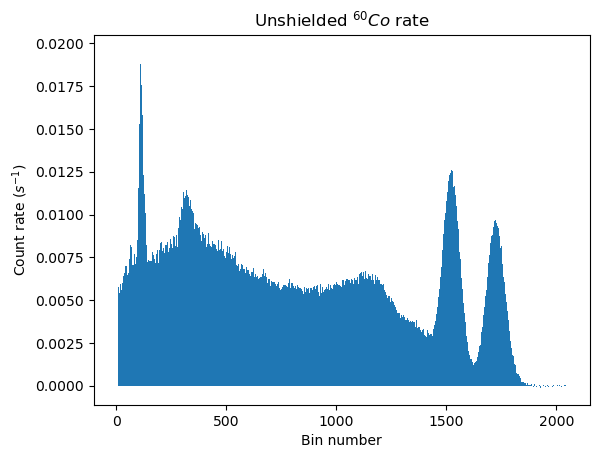

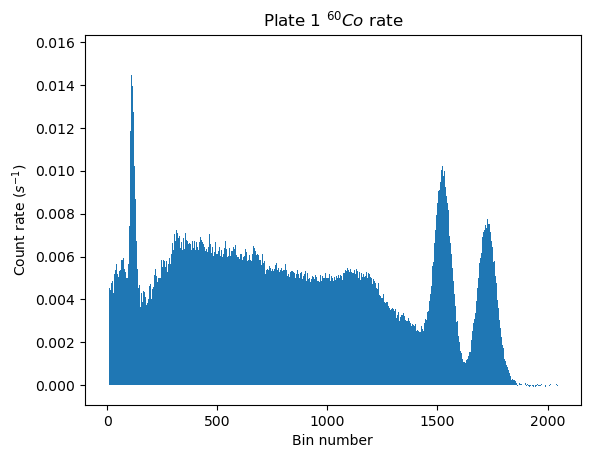

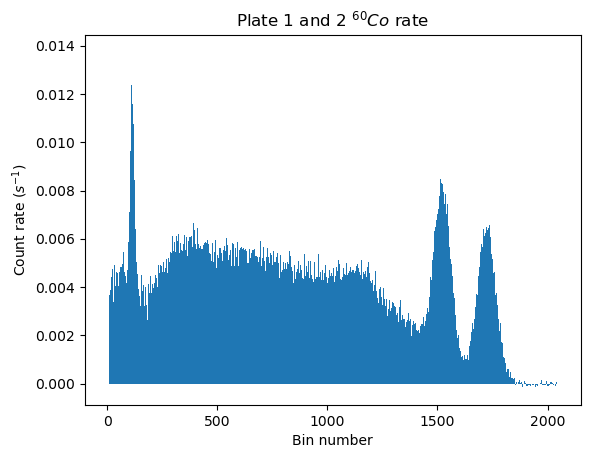

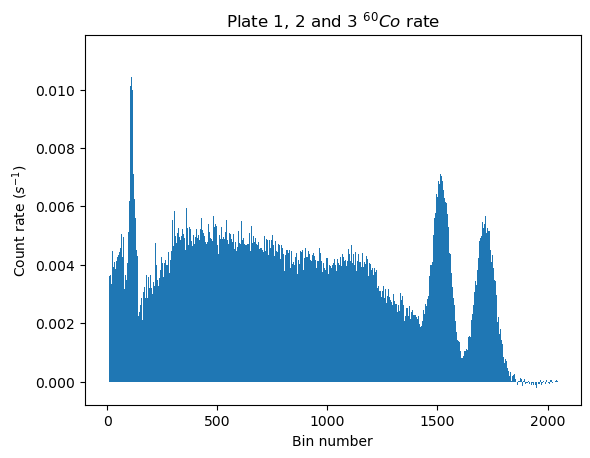

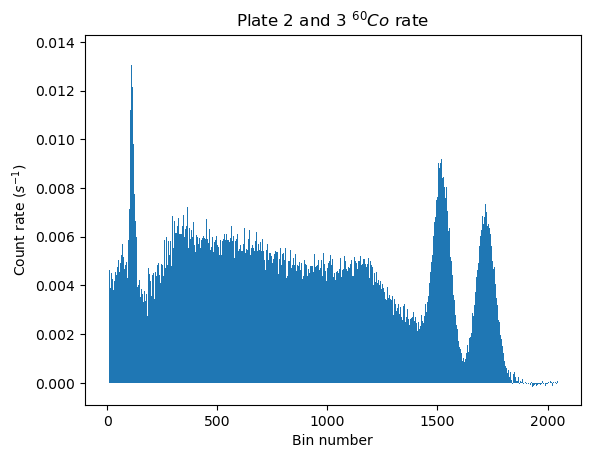

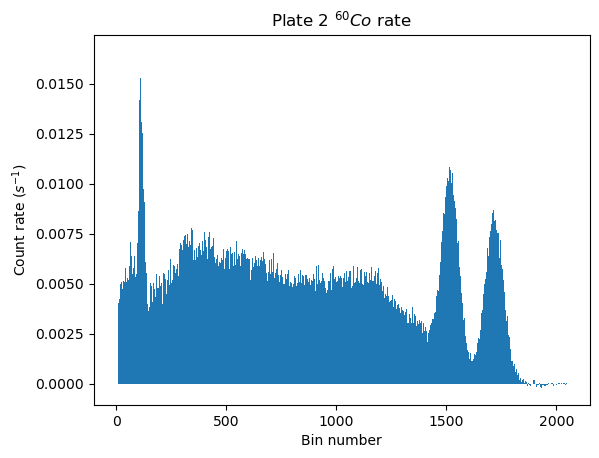

In [12]:
plate_0_rate = background_subtraction_plot(co_no_list, back_list, [r'Unshielded $^{60}Co$ rate'], 2048)
plate_1_rate = background_subtraction_plot(co_1_list, back_list, [r'Plate 1 $^{60}Co$ rate'], 2048)
plate_12_rate = background_subtraction_plot(co_12_list, back_list, [r'Plate 1 and 2 $^{60}Co$ rate'], 2048)
plate_123_rate = background_subtraction_plot(co_123_list, back_list, [r'Plate 1, 2 and 3 $^{60}Co$ rate'], 2048)
plate_23_rate = background_subtraction_plot(co_23_list, back_list, [r'Plate 2 and 3 $^{60}Co$ rate'], 2048)
plate_2_rate = background_subtraction_plot(co_2_list, back_list, [r'Plate 2 $^{60}Co$ rate'], 2048)

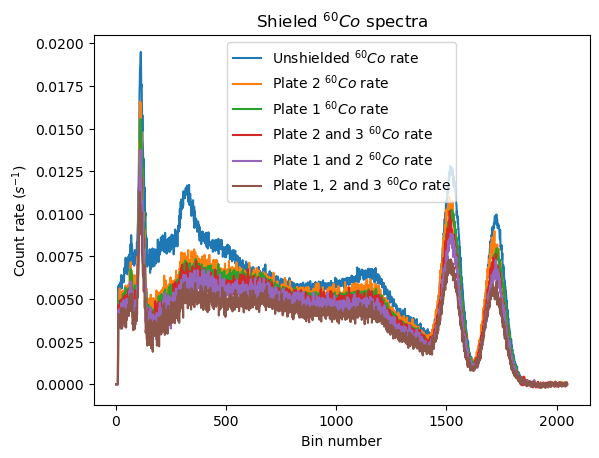

In [13]:
plt.plot(co_no_list[0], plate_0_rate, label = r'Unshielded $^{60}Co$ rate')
plt.plot(co_no_list[0], plate_2_rate, label = r'Plate 2 $^{60}Co$ rate')
plt.plot(co_no_list[0], plate_1_rate, label = r'Plate 1 $^{60}Co$ rate')
plt.plot(co_no_list[0], plate_23_rate, label = r'Plate 2 and 3 $^{60}Co$ rate')
plt.plot(co_no_list[0], plate_12_rate, label = r'Plate 1 and 2 $^{60}Co$ rate')
plt.plot(co_no_list[0], plate_123_rate, label = r'Plate 1, 2 and 3 $^{60}Co$ rate')

plt.title(r'Shieled $^{60}Co$ spectra')
plt.legend(loc = 'best')
plt.ylabel('Count rate ($s^{-1}$)')
plt.xlabel('Bin number')

plt.show()

Second of twin peaks

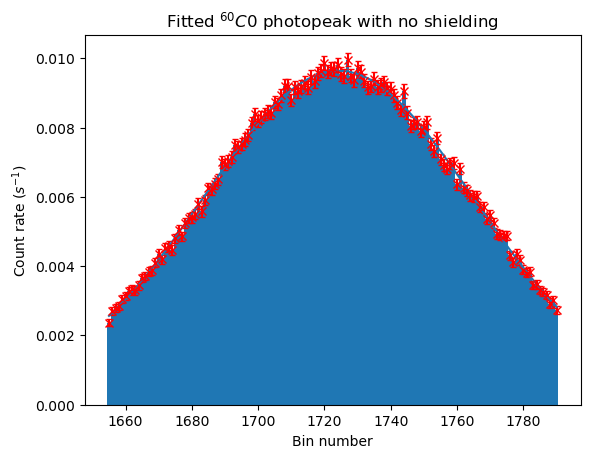

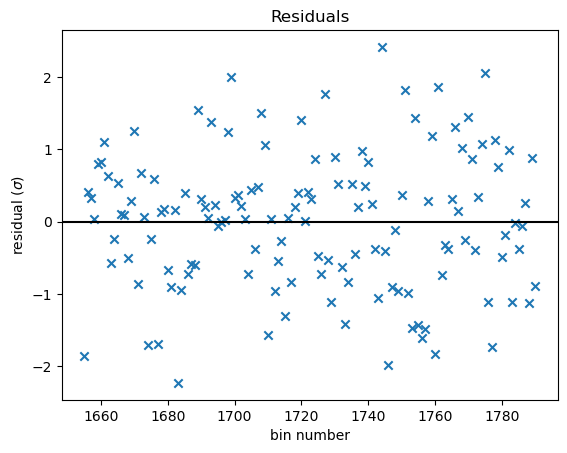

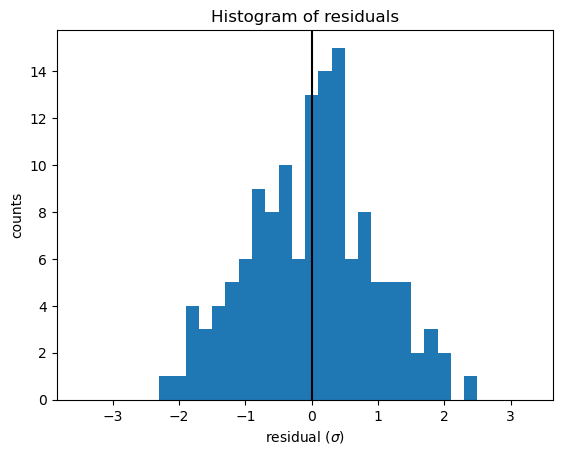

The obtained value for the peak amplitude a is:

0.0092909 +/- 0.00017 counts s^-1

The obtained value for peak centre is:

1724.3 +/- 0.33 bin
 

The obtained value for the std is:

40.68 +/- 0.71 
 

The obtained value for noise gradient is :

-6.505e-07 +/- 8.4e-07 
 

The obtained value for ofset is:

0.0014681 +/- 0.0014 
 
The fit yielded 
chi2 = 1.22e+02 with 131 degrees of freedom
giving a reduced chi2 of 0.93 

P-value = 0.7
0.9473868749352674
0.03303933803258866


In [14]:
bin_0 = [1680, 1775]


peak_0, peak_0_err = peak_fitter(co_no_list, back_list, [r'Fitted $^{60}C0$ photopeak with no shielding'], [1655, 1790])

x_0 = 0


area, area_err = peak_area(peak_0, peak_0_err)

print(area)
print(area_err)

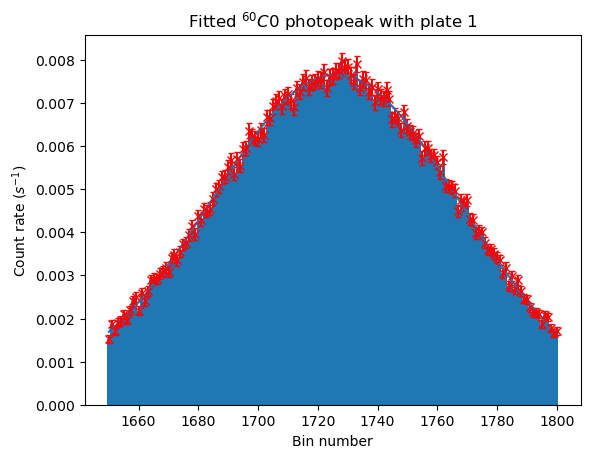

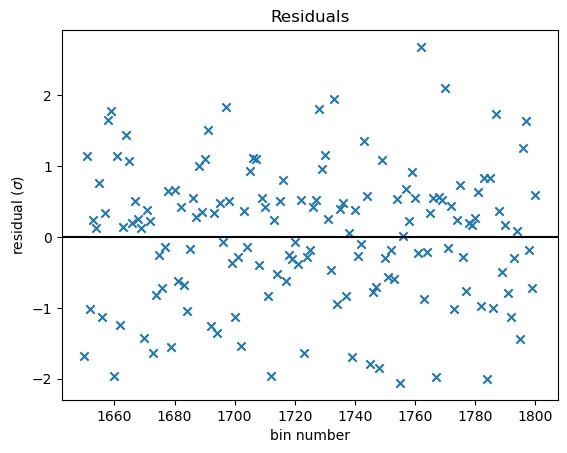

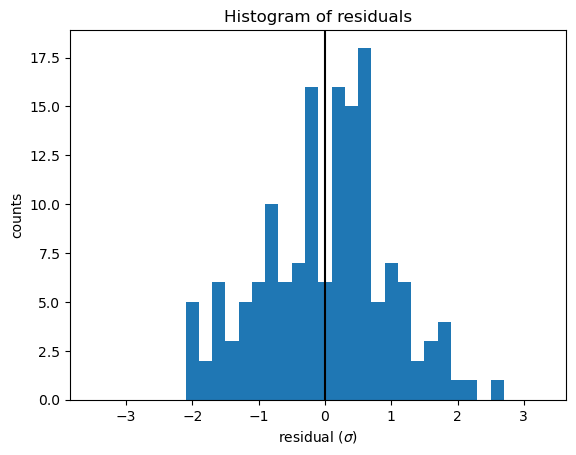

The obtained value for the peak amplitude a is:

0.0074627 +/- 0.0001 counts s^-1

The obtained value for peak centre is:

1726.4 +/- 0.32 bin
 

The obtained value for the std is:

41.635 +/- 0.62 
 

The obtained value for noise gradient is :

-1.4181e-06 +/- 5.4e-07 
 

The obtained value for ofset is:

0.0026448 +/- 0.00092 
 
The fit yielded 
chi2 = 1.39e+02 with 146 degrees of freedom
giving a reduced chi2 of 0.95 

P-value = 0.65


In [15]:


peak_1, peak_1_err = peak_fitter(co_1_list, back_list, [r'Fitted $^{60}C0$ photopeak with plate 1'], [1650, 1800])

x_1 = plate_1_avg



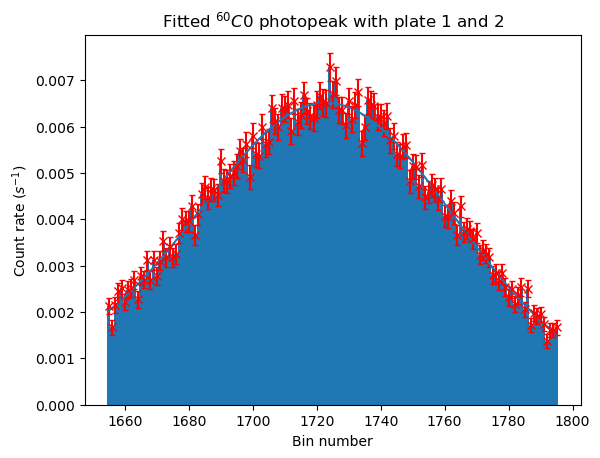

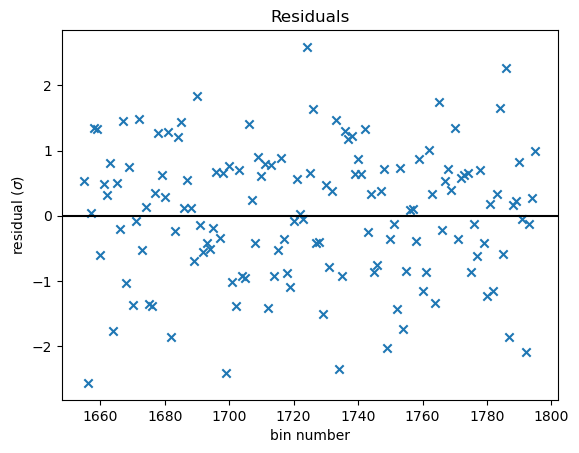

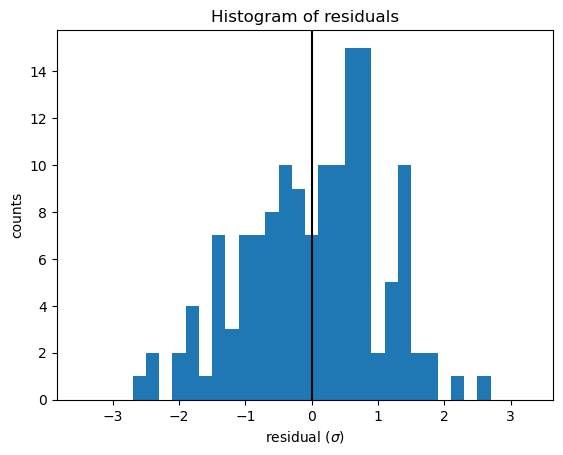

The obtained value for the peak amplitude a is:

0.0059666 +/- 0.00018 counts s^-1

The obtained value for peak centre is:

1723.5 +/- 0.65 bin
 

The obtained value for the std is:

39.364 +/- 1.3 
 

The obtained value for noise gradient is :

-2.5014e-06 +/- 1e-06 
 

The obtained value for ofset is:

0.004858 +/- 0.0018 
 
The fit yielded 
chi2 = 1.45e+02 with 136 degrees of freedom
giving a reduced chi2 of 1.07 

P-value = 0.28


In [28]:
peak_12, peak_12_err = peak_fitter(co_12_list, back_list, [r'Fitted $^{60}C0$ photopeak with plate 1 and 2'], [1655, 1795])

x_12 = plate_1_avg + plate_2_avg


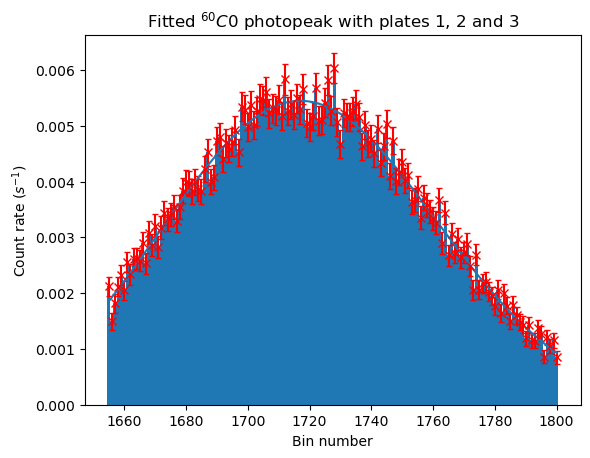

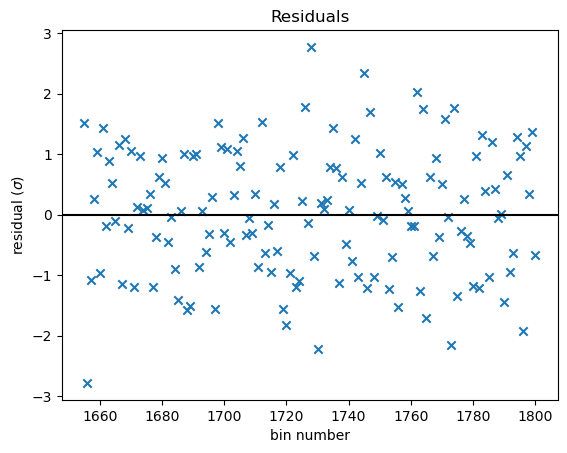

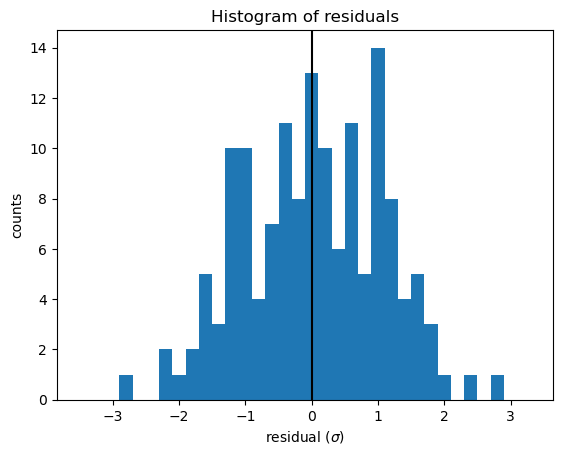

The obtained value for the peak amplitude a is:

0.0056688 +/- 0.00028 counts s^-1

The obtained value for peak centre is:

1716.3 +/- 1.1 bin
 

The obtained value for the std is:

44.636 +/- 1.9 
 

The obtained value for noise gradient is :

2.125e-06 +/- 1.7e-06 
 

The obtained value for ofset is:

-0.0038703 +/- 0.0032 
 
The fit yielded 
chi2 = 1.58e+02 with 141 degrees of freedom
giving a reduced chi2 of 1.12 

P-value = 0.16


In [38]:
peak_123, peak_123_err = peak_fitter(co_123_list, back_list, [r'Fitted $^{60}C0$ photopeak with plates 1, 2 and 3'], [1655, 1800])

x_123 = plate_1_avg + plate_2_avg + plate_3_avg

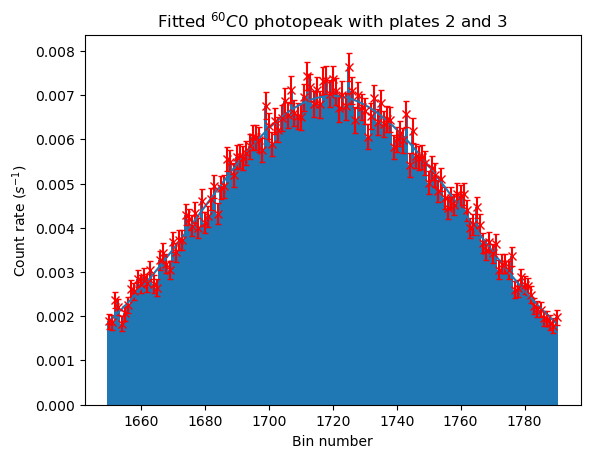

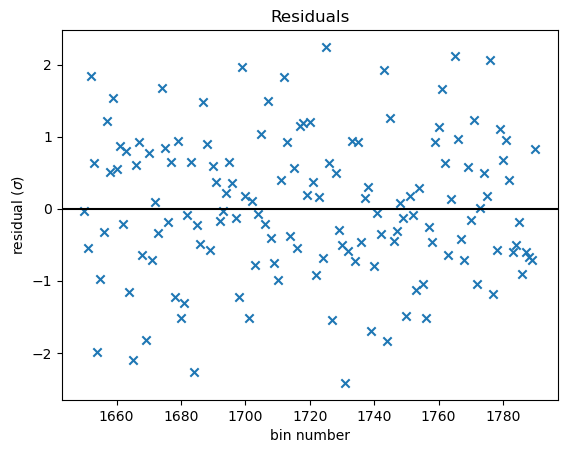

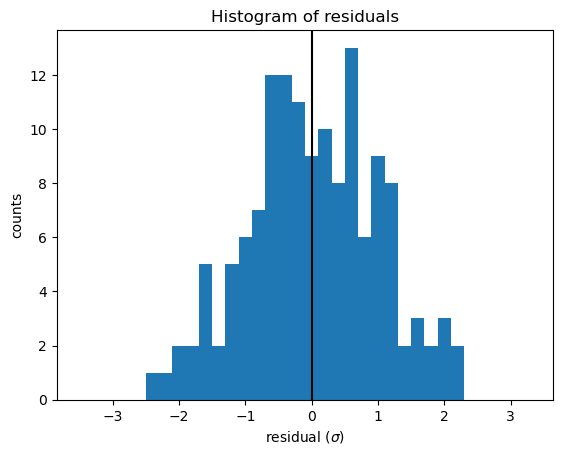

The obtained value for the peak amplitude a is:

0.0066806 +/- 0.00022 counts s^-1

The obtained value for peak centre is:

1719.9 +/- 0.67 bin
 

The obtained value for the std is:

41.079 +/- 1.4 
 

The obtained value for noise gradient is :

-3.0365e-07 +/- 1.1e-06 
 

The obtained value for ofset is:

0.0008215 +/- 0.002 
 
The fit yielded 
chi2 = 1.36e+02 with 136 degrees of freedom
giving a reduced chi2 of 1.0 

P-value = 0.47


In [18]:
peak_23, peak_23_err = peak_fitter(co_23_list, back_list, [r'Fitted $^{60}C0$ photopeak with plates 2 and 3'], [1650, 1790])

x_23 = plate_2_avg + plate_3_avg

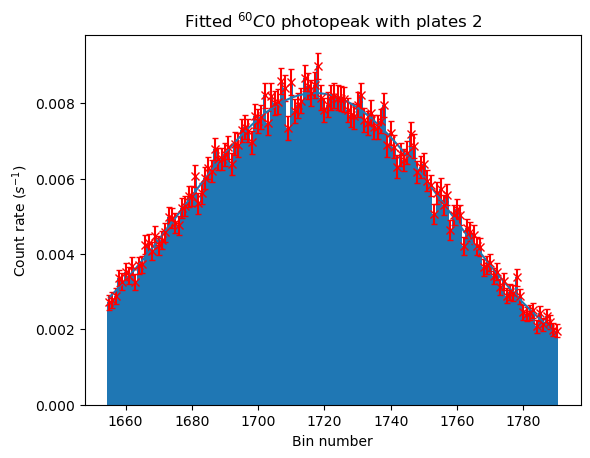

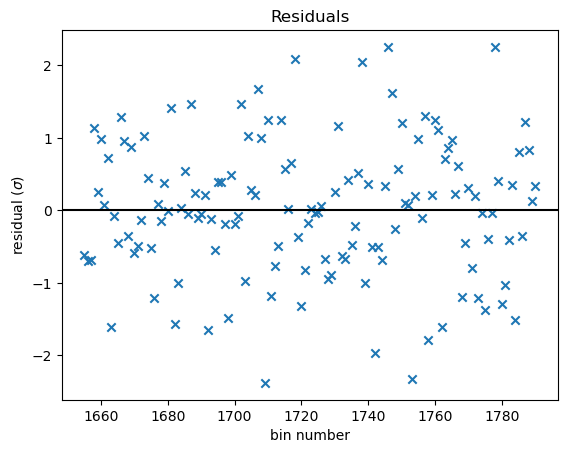

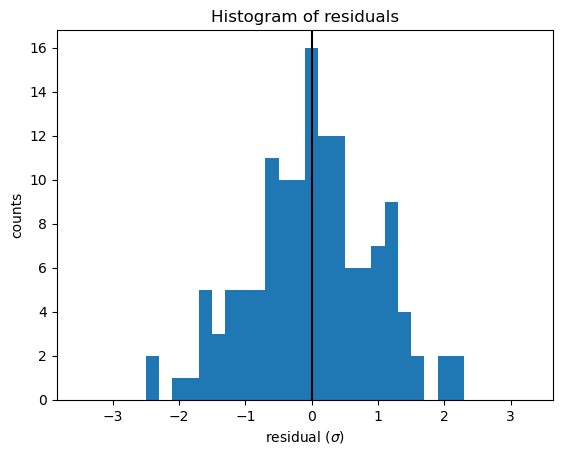

The obtained value for the peak amplitude a is:

0.007793 +/- 0.00028 counts s^-1

The obtained value for peak centre is:

1717.4 +/- 0.71 bin
 

The obtained value for the std is:

39.968 +/- 1.4 
 

The obtained value for noise gradient is :

-9.8326e-07 +/- 1.6e-06 
 

The obtained value for ofset is:

0.0021603 +/- 0.0029 
 
The fit yielded 
chi2 = 1.19e+02 with 131 degrees of freedom
giving a reduced chi2 of 0.906 

P-value = 0.77


In [27]:
peak_2, peak_2_err = peak_fitter(co_2_list, back_list, [r'Fitted $^{60}C0$ photopeak with plates 2'], [1655, 1790])

x_2 = plate_2_avg 


In [20]:
y = np.array([peak_0[0], peak_1[0], peak_12[0], peak_123[0], peak_23[0], peak_2[0]])
y_err = np.sqrt(np.array([peak_0_err[0,0], peak_1_err[0,0], peak_12_err[0,0], peak_123_err[0,0], peak_23_err[0,0], peak_2_err[0,0]]))

x = np.array([x_0, x_1, x_12, x_123, x_23, x_2]) * 1e-3


Photopeak hight

In [40]:
y = np.array([peak_0[0], peak_2[0], peak_1[0], peak_23[0], peak_12[0], peak_123[0] ])
y_err = np.sqrt(np.array([peak_0_err[0,0], peak_2_err[0,0], peak_1_err[0,0], peak_23_err[0,0], peak_12_err[0,0], peak_123_err[0,0]]))

print(y)
print(y_err)

print(y/ y_err)

x = np.array([x_0, x_2, x_1, x_23, x_12, x_123]) * 1e-3


[0.0092909  0.00779298 0.00746272 0.00668056 0.00596664 0.00566875]
[0.00016624 0.00028094 0.00010089 0.00022457 0.00018239 0.00028307]
[55.88879434 27.73847107 73.96856376 29.74868964 32.71312784 20.02582862]


0.0051598

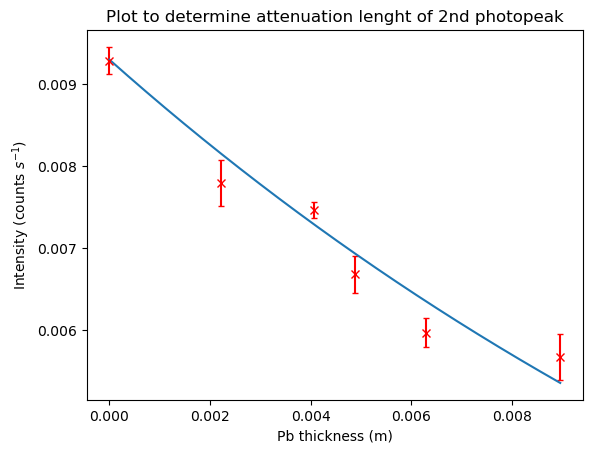

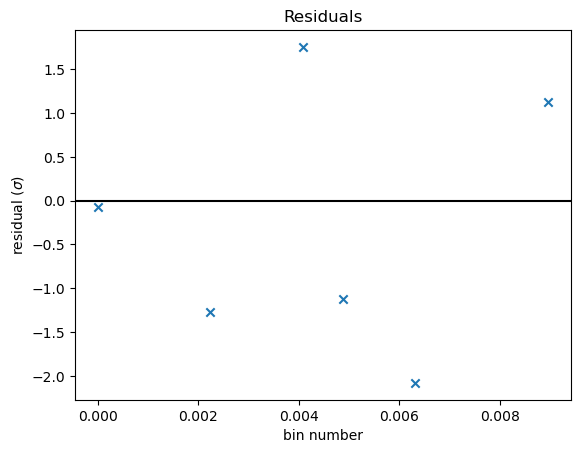

The obtained value for the peak intensity a is:

0.010944 +/- 0.015 counts s^-1

The obtained value for mean free path :

0.020003 +/- 0.034 m 
 

The obtained off set is :

-0.0016412 +/- 0.015 
 
The fit yielded 
chi2 = 11.5 with 3 degrees of freedom
giving a reduced chi2 of 3.84 

P-value = 0.0092


In [41]:
# expinential fit

# initial guesses for fit parameters
a_InitialGuess = y[0]  # Initial intensity
b_InitialGuess = 1  
c_InitialGuess = min(y)
fit_consts = [a_InitialGuess, b_InitialGuess, c_InitialGuess]  


popt, pcov = optimize.curve_fit(exp_decay, x, y, p0 = fit_consts, sigma = y_err)  # Optimised fit 

errors = np.sqrt(np.diag(pcov))  # Error on fit constants

# Extratcting fitted values with their errors 
a = popt[0]
a_err = errors[0]
b = popt[1]
b_err = errors[1]
c = popt[2]
c_err = errors[2]


y_fit = exp_decay(x, a, b, c)

x_fitted = np.linspace(min(x), max(x), 5000)
y_fitted = exp_decay(x_fitted, a, b, c)


#plt.figure(dpi=300)
plt.errorbar(x, y, yerr =  y_err, fmt ='rx', capsize = 2)
plt.plot(x_fitted, y_fitted, marker=None) 


plt.ylabel(r'Intensity (counts $s^{-1}$)')
plt.xlabel(r'Pb thickness (m)')
plt.title(r'Plot to determine attenuation lenght of 2nd photopeak')
plt.show()

# Determining chi^2
residuals = y - exp_decay(x, *popt)
chi_square = np.sum(((residuals) /(y_err)) ** 2)
            
# Determining gegreese of freedom
dof = len(x) - len(popt)
        
# Calculating p-value
chi2 = stats.chi2 
p_value = chi2.sf(chi_square, dof)

#creating a residual plot
#plt.figure(dpi=300)
plt.scatter(x, residuals/y_err, marker = "x")
plt.axhline(y=0, color='black')
plt.ylabel('residual ($\sigma$)')
plt.xlabel('bin number')
plt.title('Residuals')
#plt.savefig()
plt.show()

    
#displaying fitted values 

print('The obtained value for the peak intensity a is:\n')
print(f'{a:.5} +/- {a_err:.2} counts s^{-1}')
print('\nThe obtained value for mean free path :\n')
print(f'{b:.5} +/- {b_err:.2} m \n ')
print('\nThe obtained off set is :\n')
print(f'{c:.5} +/- {c_err:.2} \n ')

# displaying the chi2 of the fit
print(f'The fit yielded \nchi2 = {chi_square:.3} with {dof} degrees of freedom')
print(f'giving a reduced chi2 of {chi_square/dof:.3} \n')

print(f'P-value = {p_value:.2}')

Photopeak areas

In [42]:
area_0, area_0_err = peak_area(peak_0, peak_0_err)
area_1, area_1_err = peak_area(peak_1, peak_1_err)
area_2, area_2_err = peak_area(peak_2, peak_2_err)
area_23, area_23_err = peak_area(peak_23, peak_23_err)
area_12, area_12_err = peak_area(peak_12, peak_12_err)
area_123, area_123_err = peak_area(peak_123, peak_123_err)

y = np.array([area_0, area_2, area_1, area_23, area_12, area_123])
y_err = np.array([area_0_err, area_2_err, area_1_err, area_23_err, area_12_err, area_123_err])

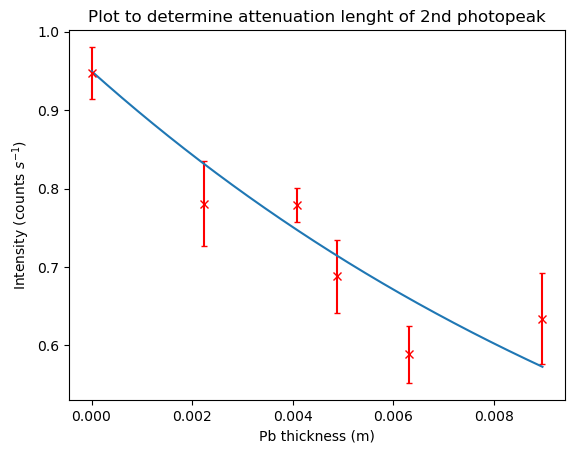

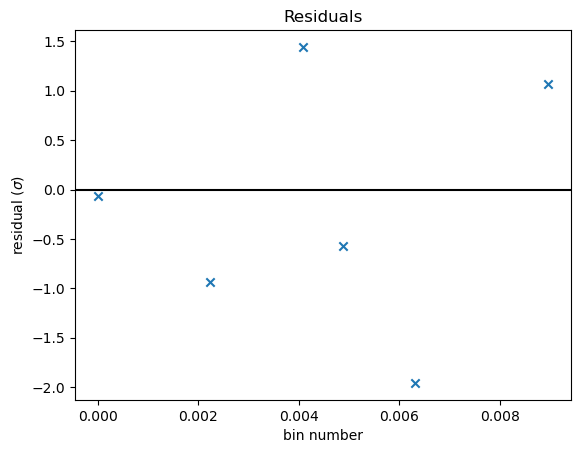

The obtained value for the peak intensity a is:

0.78382 +/- 1.3 counts s^-1

The obtained value for mean free path :

0.013677 +/- 0.029 m 
 

The obtained off set is :

0.16573 +/- 1.3 
 
The fit yielded 
chi2 = 8.27 with 3 degrees of freedom
giving a reduced chi2 of 2.76 

P-value = 0.041


In [43]:
# expinential fit

# initial guesses for fit parameters
a_InitialGuess = y[0]  # Initial intensity
b_InitialGuess = 1  
c_InitialGuess = min(y)
fit_consts = [a_InitialGuess, b_InitialGuess, c_InitialGuess]  


popt, pcov = optimize.curve_fit(exp_decay, x, y, p0 = fit_consts, sigma = y_err)  # Optimised fit 

errors = np.sqrt(np.diag(pcov))  # Error on fit constants

# Extratcting fitted values with their errors 
a = popt[0]
a_err = errors[0]
b = popt[1]
b_err = errors[1]
c = popt[2]
c_err = errors[2]


y_fit = exp_decay(x, a, b, c)

x_fitted = np.linspace(min(x), max(x), 5000)
y_fitted = exp_decay(x_fitted, a, b, c)


#plt.figure(dpi=300)
plt.errorbar(x, y, yerr =  y_err, fmt ='rx', capsize = 2)
plt.plot(x_fitted, y_fitted, marker=None) 


plt.ylabel(r'Intensity (counts $s^{-1}$)')
plt.xlabel(r'Pb thickness (m)')
plt.title(r'Plot to determine attenuation lenght of 2nd photopeak')
plt.show()

# Determining chi^2
residuals = y - exp_decay(x, *popt)
chi_square = np.sum(((residuals) /(y_err)) ** 2)
            
# Determining gegreese of freedom
dof = len(x) - len(popt)
        
# Calculating p-value
chi2 = stats.chi2 
p_value = chi2.sf(chi_square, dof)

#creating a residual plot
#plt.figure(dpi=300)
plt.scatter(x, residuals/y_err, marker = "x")
plt.axhline(y=0, color='black')
plt.ylabel('residual ($\sigma$)')
plt.xlabel('bin number')
plt.title('Residuals')
#plt.savefig()
plt.show()

    
#displaying fitted values 

print('The obtained value for the peak intensity a is:\n')
print(f'{a:.5} +/- {a_err:.2} counts s^{-1}')
print('\nThe obtained value for mean free path :\n')
print(f'{b:.5} +/- {b_err:.2} m \n ')
print('\nThe obtained off set is :\n')
print(f'{c:.5} +/- {c_err:.2} \n ')

# displaying the chi2 of the fit
print(f'The fit yielded \nchi2 = {chi_square:.3} with {dof} degrees of freedom')
print(f'giving a reduced chi2 of {chi_square/dof:.3} \n')

print(f'P-value = {p_value:.2}')